# QSVT Reports, CLI, and Artifacts

This notebook shows how diagnostics reports move between interactive Python,
JSON files, plots, and the command-line interface.

The same report structure is useful for release artifacts because it records the
polynomial coefficients, sampled errors, and boundedness checks together.

## Variable definitions

- `kind` selects the target family used by `design_workflow`.
- `degree` is the polynomial degree and `gamma` is the excluded spectral gap for sign/inverse targets.
- $P(x)$ is the designed polynomial, and `coeffs` is its ascending monomial-coefficient array.
- `report` is the JSON-safe diagnostics payload; `output_path` and `plot_path` are temporary artifact destinations.
- A sampled error is the target-minus-polynomial discrepancy on the report grid, and boundedness means $|P(x)|\le1$ on $x\in[-1,1]$.

In [1]:
from __future__ import annotations

import json
import subprocess
import sys
import tempfile
from pathlib import Path

import matplotlib.pyplot as plt

from qsvt.reports import load_report, save_report, save_report_plot
from qsvt.workflow import design_workflow

## Build a Structured Design Report

`design_workflow` returns coefficients, approximation diagnostics, and QSVT
compatibility metadata from one call.

In [2]:
result = design_workflow(
    "sign",
    gamma=0.25,
    degree=9,
    num_points=401,
    bounded_num_points=801,
    attempt_synthesis=False,
)
report = result.as_report()
print(report["mode"], report["kind"], report["builder"])
print("Degree [polynomial degree]:", result.diagnostics["degree"])
print("Max error:", result.diagnostics["max_error"])
print("Bounded margin:", result.diagnostics["bounded_margin"])

design-workflow sign design_sign_polynomial
Degree [polynomial degree]: 9
Max error: 0.24846221549762104
Bounded margin: -8.881784197001252e-15


## Save JSON and Plot Artifacts

The report helpers convert NumPy arrays and scalars into JSON-safe containers
before writing to disk.

In [3]:
with tempfile.TemporaryDirectory() as tmp:
    tmp_path = Path(tmp)
    json_path = save_report(report, tmp_path / "sign-workflow.json")
    plot_path = save_report_plot(result.diagnostics, tmp_path / "sign-workflow.png")
    loaded = load_report(json_path)

    print("JSON exists [boolean]:", json_path.exists())
    print("Plot exists [boolean]:", plot_path.exists())
    print("Loaded mode [string]:", loaded["mode"])
    print("Loaded coeff count [count]:", len(loaded["coeffs"]))

assert loaded["mode"] == "design-workflow"

JSON exists [boolean]: True
Plot exists [boolean]: True
Loaded mode [string]: design-workflow
Loaded coeff count [count]: 10


## Match the CLI Output

The package CLI can write the same kind of artifact. This cell uses a temporary
output path so the notebook leaves the repository tree unchanged.

In [4]:
with tempfile.TemporaryDirectory() as tmp:
    output_path = Path(tmp) / "cli-sign-workflow.json"
    completed = subprocess.run(
        [
            sys.executable,
            "-m",
            "qsvt",
            "design-workflow",
            "--kind",
            "sign",
            "--gamma",
            "0.25",
            "--degree",
            "9",
            "--num-points",
            "401",
            "--bounded-num-points",
            "801",
            "--no-synthesis",
            "--output",
            str(output_path),
        ],
        check=True,
        capture_output=True,
        text=True,
    )
    cli_summary = json.loads(completed.stdout)
    cli_report = json.loads(output_path.read_text(encoding="utf-8"))

print("CLI design-workflow summary")
print("---------------------------")
print(f"Mode [string]           : {cli_summary['mode']}")
print(f"Report written [path] : {cli_summary['report_written']}")
print(f"Plot written [path]   : {cli_summary['plot_written']}")
print(f"Output path [path]    : {Path(cli_summary['output']).name}")
print(f"Report kind [string]    : {cli_report['kind']}")
print(f"Coefficients [count]   : {len(cli_report['coeffs'])}")

assert cli_report["mode"] == report["mode"]
assert cli_report["kind"] == report["kind"]

CLI design-workflow summary
---------------------------
Mode [string]           : design-workflow
Report written [path] : True
Plot written [path]   : False
Output path [path]    : cli-sign-workflow.json
Report kind [string]    : sign
Coefficients [count]   : 10


## Compare Report Families

Different design kinds share common diagnostic fields, which makes them easy to
summarize in a table or release note.

In [5]:
families = [
    ("sign", "Sign", {"gamma": 0.25}),
    ("filter", "Filter", {"cutoff": 0.45, "sharpness": 10.0}),
    (
        "interval_projector",
        "Interval Projector",
        {"lower": -0.3, "upper": 0.35, "sharpness": 10.0},
    ),
]
rows = []
for kind, label, kwargs in families:
    item = design_workflow(
        kind,
        degree=9,
        num_points=401,
        bounded_num_points=801,
        attempt_synthesis=False,
        **kwargs,
    )
    rows.append(
        (
            label,
            item.diagnostics["max_error"],
            item.diagnostics["bounded_margin"],
            item.compatibility["parity"],
        )
    )

for kind, max_error, margin, parity in rows:
    print(
        f"{kind:18s} max_error={max_error:.3e}, "
        f"margin={margin:.3e}, parity [polynomial parity]={parity}"
    )

Sign               max_error=2.485e-01, margin=-8.882e-15, parity [polynomial parity]=odd
Filter             max_error=2.284e-01, margin=-1.998e-15, parity [polynomial parity]=even
Interval Projector max_error=1.968e-01, margin=0.000e+00, parity [polynomial parity]=mixed


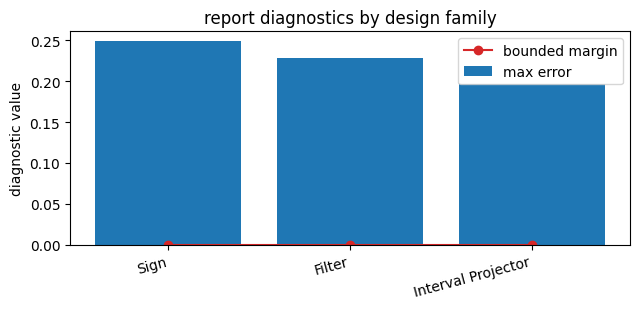

In [6]:
fig, ax = plt.subplots(figsize=(6.5, 3.2))
labels = [row[0] for row in rows]
errors = [row[1] for row in rows]
margins = [row[2] for row in rows]
positions = range(len(rows))
ax.bar(positions, errors, label="max error")
ax.plot(list(positions), margins, "o-", color="tab:red", label="bounded margin")
ax.set_xticks(list(positions), labels, rotation=15, ha="right")
ax.set_ylabel("diagnostic value")
ax.set_title("report diagnostics by design family")
ax.legend(loc="best")
fig.tight_layout()
assert all(error >= 0 for error in errors)